In [1]:
import torch as th
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.io import loadmat

FONT_SIZE   = 16
TICK_SIZE   = 16
LEGEND_SIZE = 16
AXES_SIZE   = 16

#plt.rcParams.update({"font.size": 22})

plt.rc('font',   size=FONT_SIZE)           # controls default text sizes
plt.rc('axes',   labelsize=AXES_SIZE)      # font size of the x and y labels
plt.rc('xtick',  labelsize=TICK_SIZE)      # font size of the tick labels
plt.rc('ytick',  labelsize=TICK_SIZE)      # font size of the tick labels
plt.rc('legend', fontsize=LEGEND_SIZE)     # legend font size

In [26]:
data_path = '../Giulia/dataset_stiffflop/Merged_datasets/dataset_res_act_sens_pos_1.mat'

data_res_act_sens_pos = loadmat(data_path)['Dataset']

actuations = data_res_act_sens_pos[:, :3]
resistances = data_res_act_sens_pos[:, 3:6]
tip_pos = data_res_act_sens_pos[:, 6:9]

print(data_res_act_sens_pos.shape)

(10801, 9)


In [37]:
data_path = '../Giulia/dataset_stiffflop/prova_1.mat'

data = loadmat(data_path)

sensors = data['sensors']  # # (10801, 3)
actuation = data['actuations'] # (10801, 3)
stats = data['stats']  # (1, 10801)

In [2]:
train_path = '../method_6/data/var_tr_128_9.pth'

history = th.load(train_path)

loss_train = history['loss_tr_n']
loss_val   = history['loss_val']
pred_val   = history['pred_val']
train_time = history['train_sec']

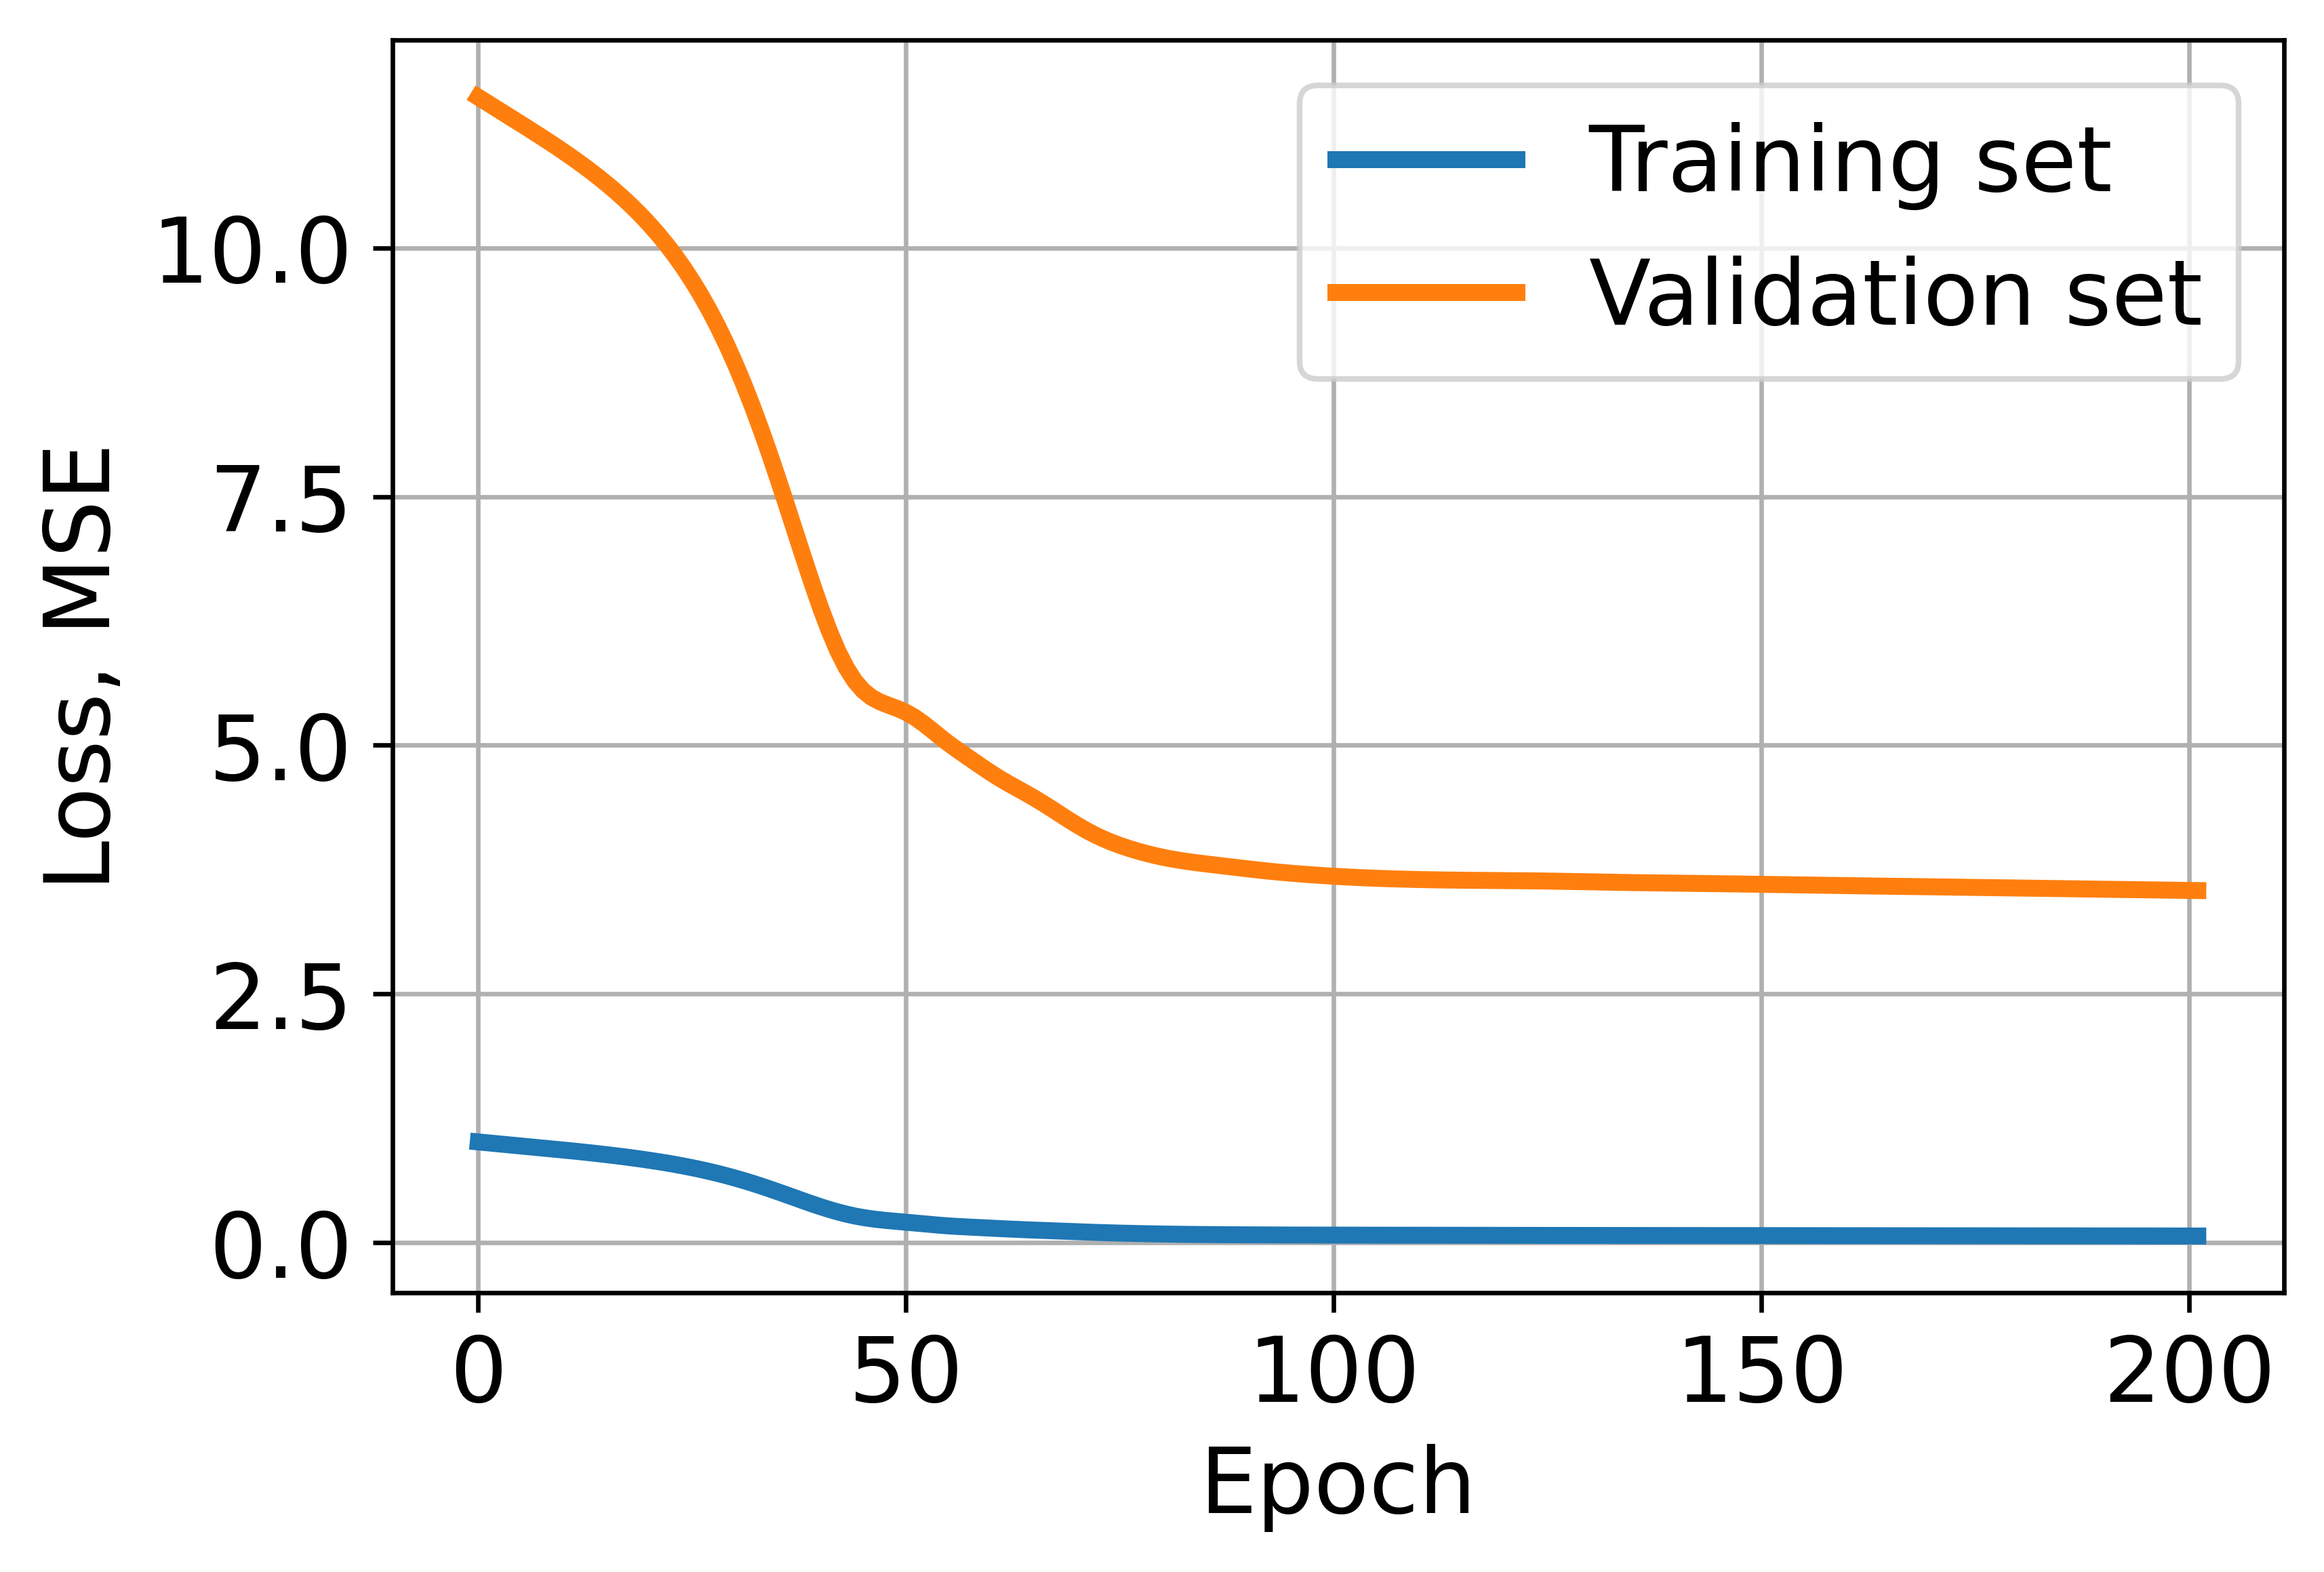

In [3]:
fig = plt.figure(figsize=(6,4), dpi=600)
plt.plot(loss_train, linewidth=3, label='Training set')
plt.plot(loss_val, linewidth=3, label='Validation set')
plt.xlabel('Epoch')
plt.ylabel('Loss, MSE')

plt.grid()
plt.legend(loc='best')
plt.show()

In [4]:
model_path = '../method_6/models/model_64_9.pth'

model_params = th.load(model_path)
model_params

OrderedDict([('lstm.weight_ih_l0',
              tensor([[-4.1726e-03,  1.4380e-01,  6.4367e-04],
                      [ 6.7812e-02,  2.7533e-02, -1.0908e-01],
                      [-9.8232e-02,  1.2885e-01,  5.6430e-02],
                      [ 3.7038e-02,  5.5016e-02, -4.6539e-02],
                      [ 1.0735e-01, -8.4117e-03, -9.5297e-02],
                      [ 9.5962e-02,  4.1230e-02, -7.7109e-02],
                      [ 1.1776e-01, -6.0829e-02,  8.1926e-03],
                      [-1.8001e-02,  9.9829e-02,  8.1896e-02],
                      [ 5.1400e-02, -8.2690e-02,  6.0128e-02],
                      [ 6.6096e-02, -1.2799e-01, -4.2208e-02],
                      [ 9.0680e-02,  1.7771e-01,  4.5892e-03],
                      [ 1.6327e-01, -6.6710e-02, -2.0382e-02],
                      [ 4.5205e-02, -4.5889e-02,  1.7511e-01],
                      [ 4.4624e-02, -1.0968e-01,  1.7294e-01],
                      [ 7.8361e-02, -2.6880e-03, -4.1154e-02],
                    

In [6]:
performance_path = '../method_6/Performances.csv'

# model_neurons_horizon
df = pd.read_csv(performance_path, header=None, index_col=False)

In [7]:
unit_32 = df.iloc[0:3]
unit_64 = df.iloc[3:6]
unit_128 = df.iloc[6:9]
#unit_32, unit_64, unit_128

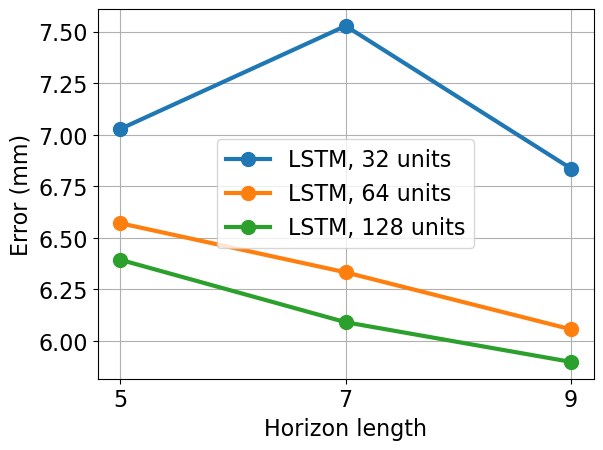

In [9]:
horizons = np.array([5,7,9])
losses_32 = unit_32[1].to_numpy()
losses_64 = unit_64[1].to_numpy()
losses_128 = unit_128[1].to_numpy()

plt.plot(horizons, losses_32/60*100, '-o', linewidth=3, markersize=10, label='LSTM, 32 units')
plt.plot(horizons, losses_64/60*100, '-o', linewidth=3, markersize=10, label='LSTM, 64 units')
plt.plot(horizons, losses_128/60*100, '-o', linewidth=3, markersize=10, label='LSTM, 128 units')

plt.xticks(horizons)
plt.legend(loc='best')

plt.ylabel('Error (mm)')
plt.xlabel('Horizon length')
plt.grid()
plt.show()

## train m6

In [82]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as opt
import matplotlib.pyplot as plt
import scipy.io as sio
import time
import os
import pandas as pd
import scipy.signal as scs

import sys
sys.path.append('..')
sys.path.append('../Giulia/dataset_stiffflop/NN/')

from nn_functions import *

#if torch.dml.is_available():
#    device = torch.device('dml')
#else:
#    device = torch.device('cpu')

device = torch.device('cpu')

print('Device used is:')
print(device)


def prepr_sens(sensors):
    # eliminate outliers
    sensors = np.where(sensors>3, np.nan, sensors) # 3V
    sensors = np.where(sensors<1, np.nan, sensors) # 1V
    _pd_m = pd.DataFrame(sensors)
    _pd_m = _pd_m.interpolate()
    sensors = np.array(_pd_m)
    # from voltage to resistance
    V_in = 3.2 # V (input voltage) 
    R_k = 12   # Ohm (known resistance)
    sens_raw = (sensors*R_k)/(V_in - sensors)

    return sens_raw

Device used is:
cpu


In [53]:
#utente_dir = 'C:/Users/giuli/OneDrive - Scuola Superiore Sant\'Anna/dataset_stiffflop' # Giulia 
utente_dir = '../Giulia/dataset_stiffflop/' # Giulia 

dir_NN = 'NN'
dir_file_data = 'Merged_datasets'
select_sens = (0, 1, 2) #(0, 1, 2)
num_coo_pos = 3
method_used = 'method_6'

dir_model = os.path.join(utente_dir, dir_NN, method_used, 'models')
dir_plot = os.path.join(utente_dir, dir_NN, method_used, 'plots')
dir_data = os.path.join(utente_dir, dir_NN, method_used, 'data')

file_store_performance = 'Performances.csv'
dir_file_performance = os.path.join(utente_dir, dir_NN, method_used, file_store_performance)
    
if num_coo_pos == 2:
    var_file = 'var_tr_xy_' + str(select_sens)[1:-1:3] + '_'
    model_file = 'model_xy_' + str(select_sens)[1:-1:3] + '_'
    init_fig2 = 'Training_xy_' + str(select_sens)[1:-1:3] + '_'
    init_fig3 = 'Val_error_xy_' + str(select_sens)[1:-1:3] + '_'

elif num_coo_pos == 3:
    var_file = 'var_' + str(select_sens)[1:-1:3] + '_'
    model_file = 'model_' + str(select_sens)[1:-1:3] + '_'
    init_fig2 = 'Training_' + str(select_sens)[1:-1:3] + '_'
    init_fig3 = 'Val_error_' + str(select_sens)[1:-1:3] + '_'

print(dir_file_performance)
print(var_file)
print(model_file)
print(init_fig2)
print(init_fig3)

../Giulia/dataset_stiffflop/NN/method_6/Performances.csv
var_012_
model_012_
Training_012_
Val_error_012_


In [83]:
# DIVISION TRAINING AND VALIDATION SET

trial_train = [2, 3]
trial_val = [1]

name_dataset = 'dataset_res_sens_pos_'
list_train_file = []
list_val_file = []

for wt in trial_train:
    list_train_file.append(name_dataset + str(wt) + '.mat')

for wv in trial_val:
    list_val_file.append(name_dataset + str(wv) + '.mat')

prepr_dataset_circ = sio.loadmat(os.path.join(utente_dir, dir_file_data, list_train_file[0]))['Dataset']
pos_out = prepr_dataset_circ[:, 3:6]
sens_in = prepr_dataset_circ[:, 0:3]
pos_out = pos_out[:, 0:num_coo_pos]
sens_circ = prepr_sens(sens_in)
sens_circ = sens_circ[:, select_sens]
tr_sens = sens_circ
tr_pos_tot = pos_out

for datasets in list_train_file[1::]:
    prepr_dataset_circ = sio.loadmat(os.path.join(utente_dir, dir_file_data, datasets))['Dataset']
    pos_out = prepr_dataset_circ[:, 3:6]
    sens_in = prepr_dataset_circ[:, 0:3]
    pos_out = pos_out[:, 0:num_coo_pos]
    sens_circ = prepr_sens(sens_in)
    sens_circ = sens_circ[:, select_sens]
    tr_sens = np.concatenate((tr_sens, sens_circ))
    tr_pos_tot = np.concatenate((tr_pos_tot, pos_out))

prepr_dataset_circ = sio.loadmat(os.path.join(utente_dir, dir_file_data, list_val_file[0]))['Dataset']
pos_out = prepr_dataset_circ[:, 3:6]
sens_in = prepr_dataset_circ[:, 0:3]
pos_out = pos_out[:, 0:num_coo_pos]
sens_circ = prepr_sens(sens_in)
sens_circ = sens_circ[:, select_sens]
val_sens = sens_circ
val_pos_tot = pos_out

for datasets in list_val_file[1::]:
    prepr_dataset_circ = sio.loadmat(os.path.join(utente_dir, dir_file_data, datasets))['Dataset']
    pos_out = prepr_dataset_circ[:, 3:6]
    sens_in = prepr_dataset_circ[:, 0:3]
    pos_out = pos_out[:, 0:num_coo_pos]
    sens_circ = prepr_sens(sens_in)
    sens_circ = sens_circ[:, select_sens]
    val_sens = np.concatenate((val_sens, sens_circ))
    val_pos_tot = np.concatenate((val_pos_tot, pos_out))

#f_s, a_s = plt.subplots(val_pos_tot.shape[1], 1)
#for ss in range(len(select_sens)):
#     a_s[ss].plot(val_pos_tot[:, ss], color = 'r')
#     a_s[ss].plot(val_sens[:, ss])
#plt.show()

tr_sens_or = tr_sens  # (21602, 3)
val_sens_or = val_sens # (10801, 3)

val_sens_or.shape

In [84]:
# # FILTERING WITH SMA (simple moving average)
window_sma = 11
#padding
tr_sens = np.vstack((np.ones((window_sma*2, tr_sens_or.shape[-1]))*tr_sens_or[0, :], tr_sens_or, np.ones((window_sma*2, tr_sens_or.shape[-1]))*tr_sens_or[-1, :]))
val_sens = np.vstack((np.ones((window_sma*2, val_sens_or.shape[-1]))*val_sens_or[0, :], val_sens_or, np.ones((window_sma*2, val_sens_or.shape[-1]))*val_sens_or[-1, :]))
# val_sens = np.vstack((np.ones((window_sma, val_sens.shape[-1]))*val_sens[0, :], val_sens, np.ones((window_sma, val_sens.shape[-1]))*val_sens[-1, :]))

tr_sens_f = np.convolve(tr_sens[:, 0], np.ones(window_sma)/window_sma).reshape(-1, 1)
val_sens_f = np.convolve(val_sens[:, 0], np.ones(window_sma)/window_sma).reshape(-1, 1)

for col in range(1, val_sens.shape[1]):
    tr_sens_f = np.hstack((tr_sens_f, np.convolve(tr_sens[:, col], np.ones(window_sma)/window_sma).reshape(-1, 1)))
    val_sens_f = np.hstack((val_sens_f, np.convolve(val_sens[:, col], np.ones(window_sma)/window_sma).reshape(-1, 1)))

gap_tr = np.abs(tr_sens_f.shape[0] - tr_pos_tot.shape[0])
gap_val = np.abs(val_sens_f.shape[0] - val_pos_tot.shape[0])

gap_tr_r = gap_tr - (gap_tr//2)
gap_val_r = gap_val - (gap_val//2)

tr_sens_f = tr_sens_f[gap_tr//2:-(gap_tr_r), :]
val_sens_f = val_sens_f[gap_val//2:-(gap_val_r), :]

pos_mu = np.mean(tr_pos_tot, axis = 0).reshape(1, -1)
pos_ss = np.std(tr_pos_tot, axis = 0).reshape(1, -1)
sens_mu = np.mean(tr_sens_f, axis = 0).reshape(1, -1)
sens_ss = np.std(tr_sens_f, axis = 0).reshape(1, -1)

sens_r_tr = (tr_sens_f - sens_mu)/sens_ss
sens_r_val = (val_sens_f - sens_mu)/sens_ss

pos_r_tr = (tr_pos_tot - pos_mu)/pos_ss
pos_r_val = val_pos_tot

#f_p, a_p = plt.subplots(tr_sens_f.shape[1], 1)
#for coo in range(num_coo_pos):
#    a_p[coo].plot(sens_r_tr[:, coo])
#    a_p[coo].plot(sens_r_val[:, coo])

#plt.show()

print(sens_r_tr.shape) # (21602, 3)
print(sens_r_val.shape) # (10801, 3)

(21602, 3)
(10801, 3)


In [85]:
# TRASFORM TO TORCH TENSOR (2D) - cut first 30 elements for training
sens_tens_tr = torch.tensor(sens_r_tr[30:, :], dtype=torch.float32).to(device)
pos_tens_tr = torch.tensor(pos_r_tr[30:, :], dtype=torch.float32).to(device)

sens_tens_val = torch.tensor(sens_r_val, dtype=torch.float32).to(device)
pos_tens_val = torch.tensor(pos_r_val, dtype=torch.float32).to(device)

pos_mean = torch.tensor(pos_mu, dtype=torch.float32).T.to(device)
pos_std = torch.tensor(pos_ss, dtype=torch.float32).T.to(device)

In [86]:
sens_tens_tr.shape, pos_tens_tr.shape, sens_tens_val.shape, pos_tens_val.shape

(torch.Size([21572, 3]),
 torch.Size([21572, 3]),
 torch.Size([10801, 3]),
 torch.Size([10801, 3]))

In [87]:
# HYPERPARAMETERS AND CREATION BATCHES (SLIDING WINDOW ON DATA)

hidden_size_lstm = 128 #hs[hh]
seq_length = 9 #sl[kk]


sens_tr_n = sens_tens_tr.unfold(0, seq_length, 1).transpose(-2, -1).to(device)

print(str(sens_tr_n.shape) + ' size of batched training input')
pos_tr_n = pos_tens_tr.unfold(0,seq_length, 1).transpose(-2, -1).to(device)
pos_tr_n_c = pos_tr_n[:, -1, :].to(device)
print(str(pos_tr_n_c.shape) + ' size of batched training ouput')

sens_val_n = sens_tens_val.unfold(0,seq_length, 1).transpose(-2, -1).to(device)
print(str(sens_val_n.shape) + ' size of batched validation input')
pos_val_n = pos_tens_val.unfold(0,seq_length, 1).transpose(-2, -1).to(device)
pos_val_n_c = pos_val_n[:, -1, :].to(device)
print(str(pos_val_n_c.shape) + ' size of batched training ouput')

torch.Size([21564, 9, 3]) size of batched training input
torch.Size([21564, 3]) size of batched training ouput
torch.Size([10793, 9, 3]) size of batched validation input
torch.Size([10793, 3]) size of batched training ouput


In [97]:
from nn_functions import LSTM_sens2pos, training_loop

In [96]:
# CREATION OF NN AND OF OPTIMIZER AND LOSS
in_size = sens_tr_n.shape[-1]
h_size = hidden_size_lstm
n_layers = 2
out_size = pos_tr_n_c.shape[-1]
dev = device

model_s2p = LSTM_sens2pos(in_size, h_size, n_layers, out_size, dev).to(device)
loss_fn = nn.MSELoss()
optimizer = opt.Adam(model_s2p.parameters(), lr=0.0005, weight_decay=1e-4)

model_s2p

LSTM_sens2pos(
  (lstm): LSTM(3, 128, num_layers=2, batch_first=True)
  (ff): Linear(in_features=128, out_features=3, bias=True)
)

In [98]:
# TRAINING
epochs = 50

start_time = time.time()
loss_tr, loss_tr_n, loss_val, pred_tr, pred_val = training_loop(sens_tr_n, pos_tr_n_c, sens_val_n, pos_val_n_c, 
                                                                pos_mean, pos_std, model_s2p, optimizer, epochs, 
                                                                loss_fn, device)
train_sec = time.time() - start_time

loss_tr = np.sqrt(loss_tr)
loss_val = np.sqrt(loss_val)

print('Training time: [s]')
print(train_sec)

/home/carlo/anaconda3/envs/machine-learning-torch-2024/lib/python3.10/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([21564, 3])) that is different to the input size (torch.Size([43128, 3])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (43128) must match the size of tensor b (21564) at non-singleton dimension 0